# Pertemuan 11 - Unsupervised Learning: Clustering

Nama: Widya Anggara
NIM: 230401020091
Kelas: IF401


## Generate & Eksplorasi Dataset

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Generate dataset sintetis pelanggan (3 kelompok tersembunyi)
np.random.seed(42)

grp1 = np.random.normal([30, 20], [6, 8], (100, 2))
grp2 = np.random.normal([70, 55], [8, 10], (100, 2))
grp3 = np.random.normal([110, 85], [10, 8], (100, 2))

data = np.vstack([grp1, grp2, grp3])

df = pd.DataFrame(
    data,
    columns=["pendapatan_tahunan", "skor_belanja"]
)

df["usia"] = np.random.randint(18, 65, len(df))
df["gender"] = np.random.choice(["L", "P"], len(df))

print("Shape:", df.shape)
print("\nStatistik deskriptif:")
display(df.describe().round(2))

print("\n5 data pertama:")
display(df.head())


Shape: (300, 4)

Statistik deskriptif:


,pendapatan_tahunan,skor_belanja,usia
count,300.00,300.00,300.00
mean,69.96,53.23,42.07
std,33.82,27.41,13.59
min,14.28,4.10,18.00
25%,32.14,25.60,30.00
50%,70.84,55.11,43.00
75%,103.40,78.16,53.00
max,140.79,103.17,64.00



5 data pertama:


,pendapatan_tahunan,skor_belanja,usia,gender
0,32.980285,18.893886,64,P
1,33.886131,32.184239,21,P
2,28.595080,18.126904,29,L
3,39.475277,26.139478,62,L
4,27.183154,24.340480,19,L


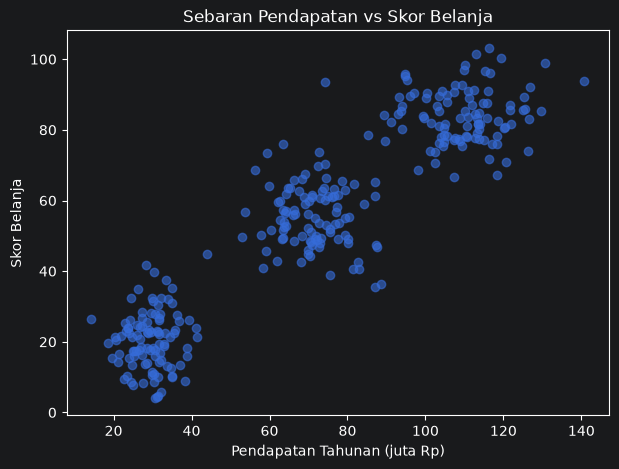

In [11]:
plt.figure(figsize=(7, 5))
plt.scatter(
    df["pendapatan_tahunan"],
    df["skor_belanja"],
    alpha=0.6
)
plt.xlabel("Pendapatan Tahunan (juta Rp)")
plt.ylabel("Skor Belanja")
plt.title("Sebaran Pendapatan vs Skor Belanja")
plt.show()


## Preprocessing Data

In [12]:
from sklearn.preprocessing import StandardScaler

X = df[["pendapatan_tahunan", "skor_belanja"]].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Rata-rata setelah scaling:", X_scaled.mean(axis=0).round(3))
print("Std setelah scaling       :", X_scaled.std(axis=0).round(3))


Rata-rata setelah scaling: [0. 0.]
Std setelah scaling       : [1. 1.]


## Metode Elbow untuk Menentukan K

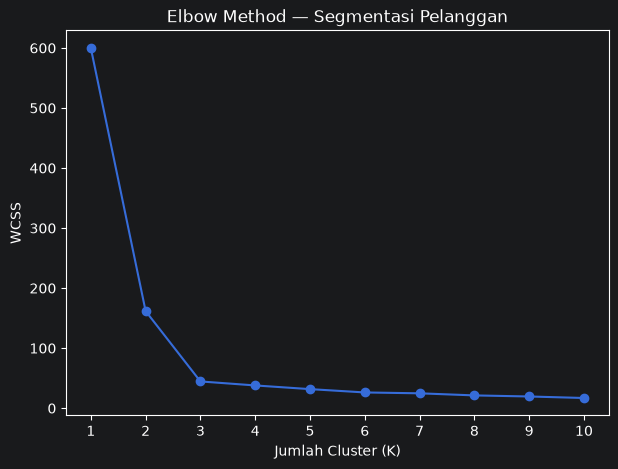

Nilai WCSS:
K=1: 600.000
K=2: 161.732
K=3: 44.556
K=4: 37.885
K=5: 31.761
K=6: 26.216
K=7: 24.772
K=8: 21.286
K=9: 19.491
K=10: 16.975


In [13]:
from sklearn.cluster import KMeans

wcss = []

for k in range(1, 11):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        init="k-means++"
    )
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(range(1, 11), wcss, marker="o")
plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method — Segmentasi Pelanggan")
plt.xticks(range(1, 11))
plt.show()

print("Nilai WCSS:")
for k, nilai in enumerate(wcss, start=1):
    print(f"K={k}: {nilai:.3f}")


In [14]:
from sklearn.metrics import silhouette_score

silhouette_results = {}

for k in range(2, 8):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        init="k-means++"
    )
    labels_k = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels_k)
    silhouette_results[k] = sil
    print(f"K={k}: Silhouette = {sil:.3f}")


K=2: Silhouette = 0.634
K=3: Silhouette = 0.695
K=4: Silhouette = 0.580
K=5: Silhouette = 0.491
K=6: Silhouette = 0.382
K=7: Silhouette = 0.357


## Melatih Model K-Means

In [15]:
model = KMeans(
    n_clusters=3,
    random_state=42,
    init="k-means++"
)

model.fit(X_scaled)

df["cluster"] = model.labels_

silhouette_final = silhouette_score(X_scaled, model.labels_)

print(f"WCSS akhir       : {model.inertia_:.3f}")
print(f"Silhouette Score : {silhouette_final:.3f}")

print("\nRata-rata karakteristik setiap cluster:")
cluster_summary = (
    df.groupby("cluster")[["pendapatan_tahunan", "skor_belanja"]]
      .mean()
      .round(2)
)
display(cluster_summary)


WCSS akhir       : 44.556
Silhouette Score : 0.695

Rata-rata karakteristik setiap cluster:


,pendapatan_tahunan,skor_belanja
cluster,,
0,70.99,55.05
1,29.31,20.27
2,109.20,84.08


## Visualisasi Hasil Clustering

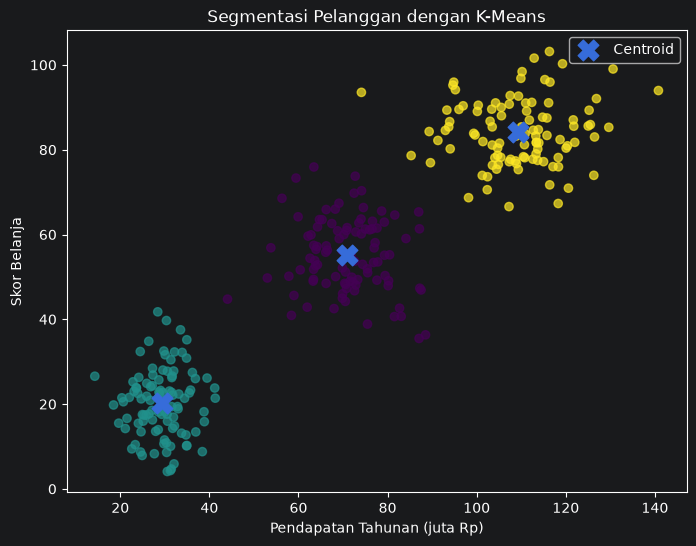

Koordinat centroid:
Cluster 0: Pendapatan=70.99, Skor Belanja=55.05
Cluster 1: Pendapatan=29.31, Skor Belanja=20.27
Cluster 2: Pendapatan=109.20, Skor Belanja=84.08


In [16]:
centroids = scaler.inverse_transform(model.cluster_centers_)

plt.figure(figsize=(8, 6))

plt.scatter(
    df["pendapatan_tahunan"],
    df["skor_belanja"],
    c=df["cluster"],
    alpha=0.7
)

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker="X",
    s=220,
    label="Centroid"
)

plt.xlabel("Pendapatan Tahunan (juta Rp)")
plt.ylabel("Skor Belanja")
plt.title("Segmentasi Pelanggan dengan K-Means")
plt.legend()
plt.show()

print("Koordinat centroid:")
for i, centroid in enumerate(centroids):
    print(
        f"Cluster {i}: "
        f"Pendapatan={centroid[0]:.2f}, "
        f"Skor Belanja={centroid[1]:.2f}"
    )


### Interpretasi Segmen Pelanggan

- **Hemat** → pendapatan rendah dan skor belanja rendah.
- **Menengah** → pendapatan dan skor belanja berada di tingkat menengah.
- **Boros/Premium** → pendapatan tinggi dan skor belanja tinggi.

## Hierarchical Clustering sebagai Pembanding

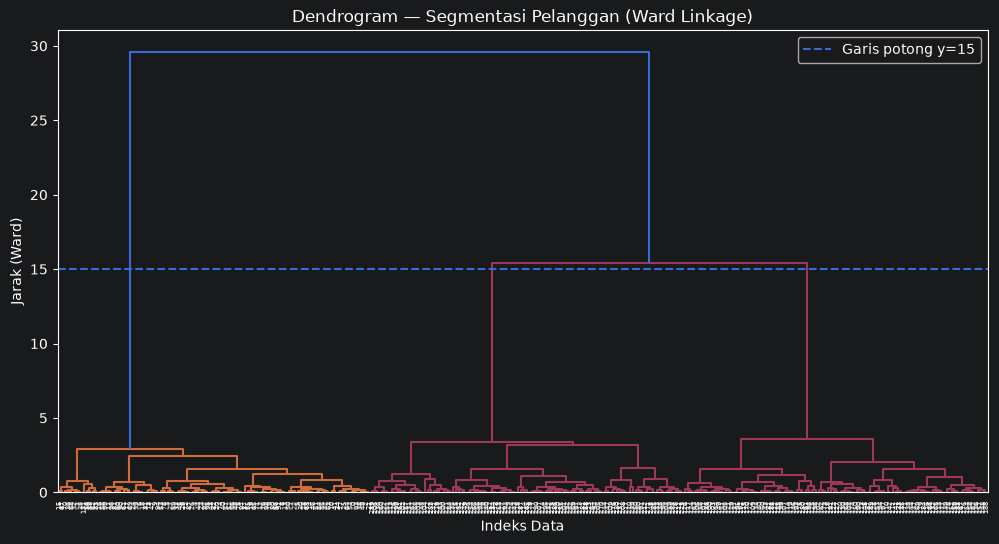

Jumlah cluster pada garis potong y=15: 3


In [17]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

Z = linkage(X_scaled, method="ward")

plt.figure(figsize=(12, 6))
dendrogram(Z)
plt.title("Dendrogram — Segmentasi Pelanggan (Ward Linkage)")
plt.xlabel("Indeks Data")
plt.ylabel("Jarak (Ward)")
plt.axhline(y=15, linestyle="--", label="Garis potong y=15")
plt.legend()
plt.show()

# Mengecek jumlah cluster jika dendrogram dipotong pada jarak 15
hier_labels = fcluster(Z, t=15, criterion="distance")
print("Jumlah cluster pada garis potong y=15:", len(np.unique(hier_labels)))


## Kesimpulan

Berdasarkan Elbow Method, kurva WCSS mulai melandai setelah **K=3**, sehingga tiga cluster dipilih sebagai jumlah cluster optimal. Silhouette Score pada K=3 sekitar **0,695**, yang menunjukkan pemisahan antar cluster cukup baik. Ketiga cluster dapat diinterpretasikan sebagai pelanggan **Hemat**, **Menengah**, dan **Boros/Premium** berdasarkan rata-rata pendapatan tahunan dan skor belanja. Hierarchical Clustering dengan Ward linkage juga menghasilkan sekitar tiga kelompok pada garis potong yang sesuai, sehingga mendukung hasil segmentasi K-Means.
